In [13]:
import xarray as xr
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import cartopy.feature as cf
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path
import matplotlib.ticker as ticker
%run 'helper_funcs.ipynb'

In [14]:
input_path = '/glade/work/ekeefe/research_code/model_output/historical_sim'
hist_run = create_big_ds(input_path)

/glade/derecho/scratch/ekeefe/tmp/ipykernel_62714/3957096376.py:22: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  big_ds = xr.open_mfdataset(files, compat='override', coords='minimal', engine='netcdf4')


In [15]:
aunz = create_big_ds('/glade/work/ekeefe/research_code/model_output/proper_output/proper_aunz_output')
bona = create_big_ds('/glade/work/ekeefe/research_code/model_output/proper_output/proper_bona_output')
tena = create_big_ds('/glade/work/ekeefe/research_code/model_output/proper_output/proper_tena_output')

/glade/derecho/scratch/ekeefe/tmp/ipykernel_62714/3957096376.py:22: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  big_ds = xr.open_mfdataset(files, compat='override', coords='minimal', engine='netcdf4')
/glade/derecho/scratch/ekeefe/tmp/ipykernel_62714/3957096376.py:22: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitl

In [16]:
hist_dust = create_big_ds('/glade/work/ekeefe/research_code/model_output/hist_with_dust')

/glade/derecho/scratch/ekeefe/tmp/ipykernel_62714/3957096376.py:22: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  big_ds = xr.open_mfdataset(files, compat='override', coords='minimal', engine='netcdf4')


In [17]:
hist_reg_dust = hist_run.PM25
hist_new_dust = hist_dust.PM25
aunz_dust = aunz.PM25
bona_dust = bona.PM25
tena_dust = tena.PM25

Text(0.5, 1.0, 'Mean Surface PM₂.₅ Concentrations, Base Scheme, 2015 - 2020')

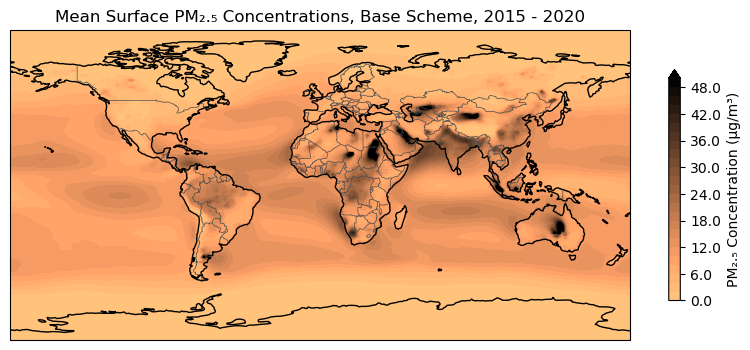

In [19]:
# Plot regular dust annually
#dust_data = hist_reg_dust.groupby('time.season').mean()
dust_data = hist_reg_dust.mean(dim='time')
dust_data = dust_data.sel(lev=max(dust_data.lev.values))

# Change longitude for plotting
if max(dust_data.lon)>350:
    dust_to_plot = dust_data.assign_coords(lon=(((dust_data.lon + 180) % 360) - 180)).sortby('lon')
dust_to_plot = dust_to_plot * 1e9

# Create the plot
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10,12))
ax = plt.axes(projection = proj)
ax.coastlines()
ax.add_feature(cf.BORDERS.with_scale('50m'), edgecolor = [.3,.3,.3], linewidth = 0.5)

dust_cyc, lon_cyc = add_cyclic_point(dust_to_plot, coord = dust_to_plot.lon)
o = ax.contourf(lon_cyc, dust_to_plot.lat, dust_cyc, transform=ccrs.PlateCarree(), cmap=matplotlib.cm.copper_r, levels=np.linspace(0,50,26), extend='max')
cb = plt.colorbar(o, extend = 'max', extendfrac = 'auto', shrink=0.25)
cb_format = ticker.FuncFormatter(lambda x, pos: f'{x*1:.1f}')
    
cb.set_label('PM₂.₅ Concentration (μg/m³)')
cb.ax.yaxis.set_major_formatter(cb_format)
plt.title(f'Mean Surface PM₂.₅ Concentrations, Base Scheme, 2015 - 2020')

Text(0.5, 1.0, 'Mean Surface PM₂.₅ Concentrations, New Scheme, 2015 - 2020')

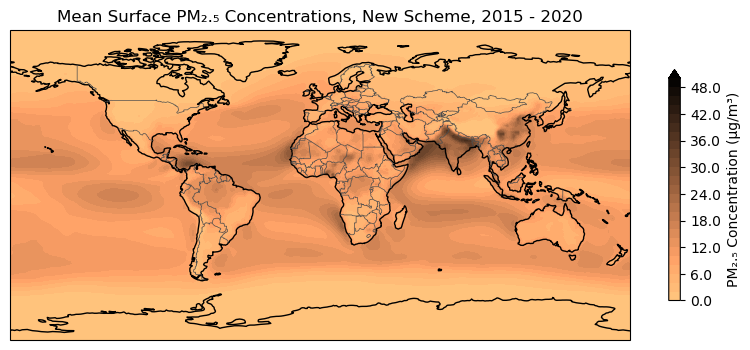

In [20]:
dust_data = hist_new_dust.mean(dim='time')
dust_data = dust_data.sel(lev=max(dust_data.lev.values))

# Change longitude for plotting
if max(dust_data.lon)>350:
    dust_to_plot = dust_data.assign_coords(lon=(((dust_data.lon + 180) % 360) - 180)).sortby('lon')
dust_to_plot = dust_to_plot * 1e9

# Create the plot
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10,12))
ax = plt.axes(projection = proj)
ax.coastlines()
ax.add_feature(cf.BORDERS.with_scale('50m'), edgecolor = [.3,.3,.3], linewidth = 0.5)

dust_cyc, lon_cyc = add_cyclic_point(dust_to_plot, coord = dust_to_plot.lon)
o = ax.contourf(lon_cyc, dust_to_plot.lat, dust_cyc, transform=ccrs.PlateCarree(), cmap=matplotlib.cm.copper_r, levels=np.linspace(0,50,26), extend='max')
cb = plt.colorbar(o, extend = 'max', extendfrac = 'auto', shrink=0.25)
cb_format = ticker.FuncFormatter(lambda x, pos: f'{x*1:.1f}')
    
cb.set_label('PM₂.₅ Concentration (μg/m³)')
cb.ax.yaxis.set_major_formatter(cb_format)
plt.title(f'Mean Surface PM₂.₅ Concentrations, New Scheme, 2015 - 2020')

In [3]:
dust_data = aunz_dust.mean(dim='time')

# Change longitude for plotting
if max(dust_data.lon)>350:
    dust_to_plot = dust_data.assign_coords(lon=(((dust_data.lon + 180) % 360) - 180)).sortby('lon')
dust_to_plot = dust_to_plot * 1e9

# Create the plot
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10,12))
ax = plt.axes(projection = proj)
ax.coastlines()
ax.add_feature(cf.BORDERS.with_scale('50m'), edgecolor = [.3,.3,.3], linewidth = 0.5)

dust_cyc, lon_cyc = add_cyclic_point(dust_to_plot, coord = dust_to_plot.lon)
o = ax.contourf(lon_cyc, dust_to_plot.lat, dust_cyc, transform=ccrs.PlateCarree(), cmap=matplotlib.cm.copper_r, levels=np.linspace(0,1000,51), extend='max')
cb = plt.colorbar(o, extend = 'max', extendfrac = 'auto', shrink=0.25)
cb_format = ticker.FuncFormatter(lambda x, pos: f'{x*1:.1f}')
    
cb.set_label('Dust Concentration (μm)')
cb.ax.yaxis.set_major_formatter(cb_format)
plt.title(f'Mean Surface Dust Concentrations, Base Scheme, AUNZ Mask, 2015 - 2019')

NameError: name 'aunz_dust' is not defined

Text(0.5, 1.0, 'Mean Surface Dust Concentrations, Base Scheme, BONA Mask, 2015 - 2019')

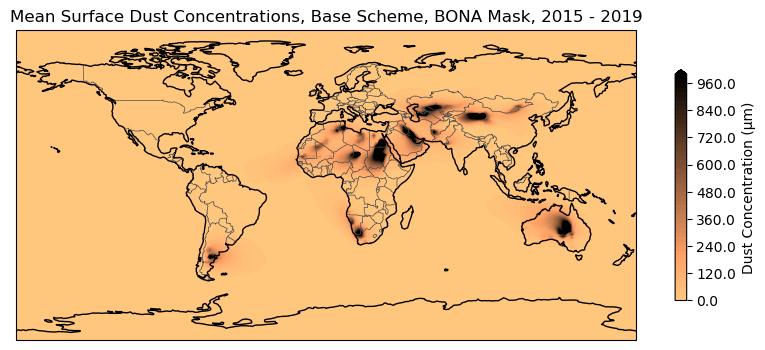

In [33]:
dust_data = bona_dust.mean(dim='time')

# Change longitude for plotting
if max(dust_data.lon)>350:
    dust_to_plot = dust_data.assign_coords(lon=(((dust_data.lon + 180) % 360) - 180)).sortby('lon')
dust_to_plot = dust_to_plot * 1e9

# Create the plot
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10,12))
ax = plt.axes(projection = proj)
ax.coastlines()
ax.add_feature(cf.BORDERS.with_scale('50m'), edgecolor = [.3,.3,.3], linewidth = 0.5)

dust_cyc, lon_cyc = add_cyclic_point(dust_to_plot, coord = dust_to_plot.lon)
o = ax.contourf(lon_cyc, dust_to_plot.lat, dust_cyc, transform=ccrs.PlateCarree(), cmap=matplotlib.cm.copper_r, levels=np.linspace(0,1000,51), extend='max')
cb = plt.colorbar(o, extend = 'max', extendfrac = 'auto', shrink=0.25)
cb_format = ticker.FuncFormatter(lambda x, pos: f'{x*1:.1f}')
    
cb.set_label('Dust Concentration (μm)')
cb.ax.yaxis.set_major_formatter(cb_format)
plt.title(f'Mean Surface Dust Concentrations, Base Scheme, BONA Mask, 2015 - 2019')

Text(0.5, 1.0, 'Mean Surface Dust Concentrations, Base Scheme, TENA Mask, 2015 - 2019')

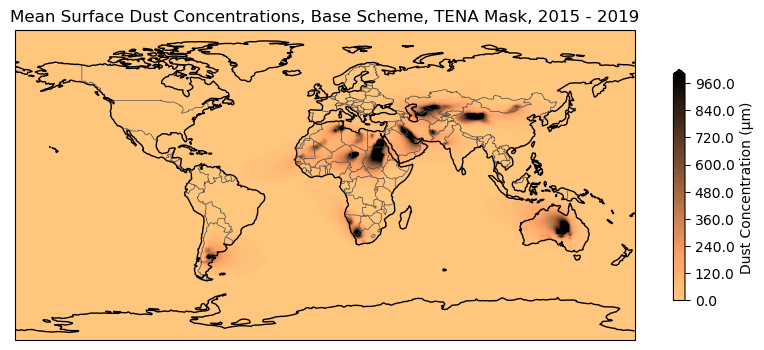

In [34]:
dust_data = tena_dust.mean(dim='time')

# Change longitude for plotting
if max(dust_data.lon)>350:
    dust_to_plot = dust_data.assign_coords(lon=(((dust_data.lon + 180) % 360) - 180)).sortby('lon')
dust_to_plot = dust_to_plot * 1e9

# Create the plot
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10,12))
ax = plt.axes(projection = proj)
ax.coastlines()
ax.add_feature(cf.BORDERS.with_scale('50m'), edgecolor = [.3,.3,.3], linewidth = 0.5)

dust_cyc, lon_cyc = add_cyclic_point(dust_to_plot, coord = dust_to_plot.lon)
o = ax.contourf(lon_cyc, dust_to_plot.lat, dust_cyc, transform=ccrs.PlateCarree(), cmap=matplotlib.cm.copper_r, levels=np.linspace(0,1000,51), extend='max')
cb = plt.colorbar(o, extend = 'max', extendfrac = 'auto', shrink=0.25)
cb_format = ticker.FuncFormatter(lambda x, pos: f'{x*1:.1f}')
    
cb.set_label('Dust Concentration (μm)')
cb.ax.yaxis.set_major_formatter(cb_format)
plt.title(f'Mean Surface Dust Concentrations, Base Scheme, TENA Mask, 2015 - 2019')

In [7]:
hist_reg_dust = hist_run.dst_a3_SRF
hist_new_dust = hist_dust.dst_a3_SRF

Text(0.5, 1.0, 'Mean Surface Dust Concentrations, Base Scheme, 2015 - 2020')

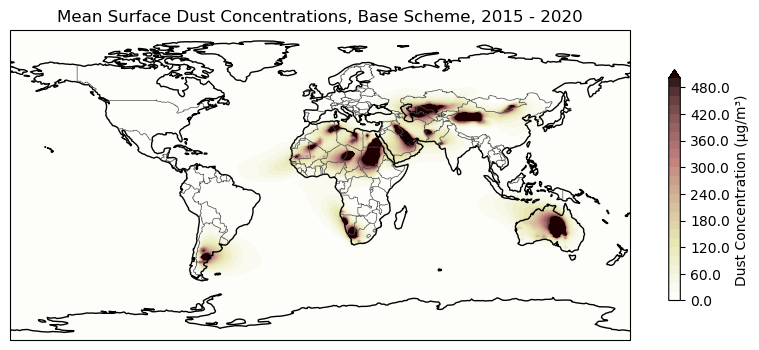

In [11]:
dust_data = hist_reg_dust.mean(dim='time')
#dust_data = dust_data.sel(lev=max(dust_data.lev.values))

# Change longitude for plotting
if max(dust_data.lon)>350:
    dust_to_plot = dust_data.assign_coords(lon=(((dust_data.lon + 180) % 360) - 180)).sortby('lon')
dust_to_plot = dust_to_plot * 1e9

# Create the plot
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10,12))
ax = plt.axes(projection = proj)
ax.coastlines()
ax.add_feature(cf.BORDERS.with_scale('50m'), edgecolor = [.3,.3,.3], linewidth = 0.5)

dust_cyc, lon_cyc = add_cyclic_point(dust_to_plot, coord = dust_to_plot.lon)
o = ax.contourf(lon_cyc, dust_to_plot.lat, dust_cyc, transform=ccrs.PlateCarree(), cmap=matplotlib.cm.pink_r, levels=np.linspace(0,500,26), extend='max')
cb = plt.colorbar(o, extend = 'max', extendfrac = 'auto', shrink=0.25)
cb_format = ticker.FuncFormatter(lambda x, pos: f'{x*1:.1f}')
    
cb.set_label('Dust Concentration (μg/m³)')
cb.ax.yaxis.set_major_formatter(cb_format)
plt.title(f'Mean Surface Dust Concentrations, Base Scheme, 2015 - 2020')

Text(0.5, 1.0, 'Mean Surface Dust Concentrations, New Scheme, 2015 - 2020')

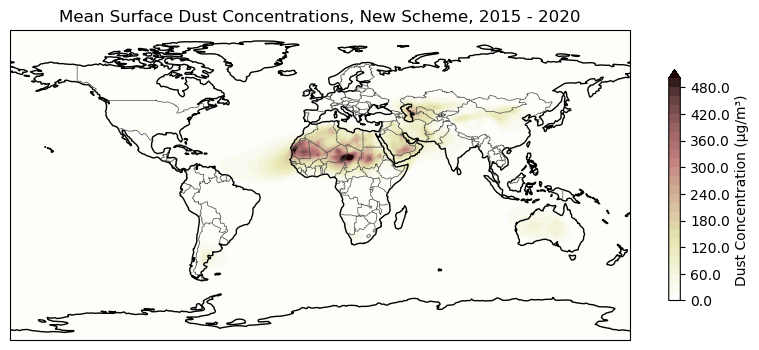

In [12]:
dust_data = hist_new_dust.mean(dim='time')
#dust_data = dust_data.sel(lev=max(dust_data.lev.values))

# Change longitude for plotting
if max(dust_data.lon)>350:
    dust_to_plot = dust_data.assign_coords(lon=(((dust_data.lon + 180) % 360) - 180)).sortby('lon')
dust_to_plot = dust_to_plot * 1e9

# Create the plot
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10,12))
ax = plt.axes(projection = proj)
ax.coastlines()
ax.add_feature(cf.BORDERS.with_scale('50m'), edgecolor = [.3,.3,.3], linewidth = 0.5)

dust_cyc, lon_cyc = add_cyclic_point(dust_to_plot, coord = dust_to_plot.lon)
o = ax.contourf(lon_cyc, dust_to_plot.lat, dust_cyc, transform=ccrs.PlateCarree(), cmap=matplotlib.cm.pink_r, levels=np.linspace(0,500,26), extend='max')
cb = plt.colorbar(o, extend = 'max', extendfrac = 'auto', shrink=0.25)
cb_format = ticker.FuncFormatter(lambda x, pos: f'{x*1:.1f}')
    
cb.set_label('Dust Concentration (μg/m³)')
cb.ax.yaxis.set_major_formatter(cb_format)
plt.title(f'Mean Surface Dust Concentrations, New Scheme, 2015 - 2020')